# Evidencia 3 — Primer análisis de datos con Python

## 1. Carga de datos
En esta sección importamos la librería `numpy` para manejar el conjunto de datos tabular sobre los ensayos clínicos de inflamación.

ALFONSO ARROYO

In [3]:
%pip install numpy

   ---------------------------------------- 0.0/12.7 MB ? eta -:--:--
   -------------------------------- ------- 10.2/12.7 MB 63.4 MB/s eta 0:00:01
   ---------------------------------------- 12.7/12.7 MB 54.3 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np

# Cargar los datos de inflamación desde el archivo CSV
data = np.loadtxt(fname='inflammation-01.csv', delimiter=',')

## 2. Exploración
Revisamos la estructura básica del conjunto de datos para entender su dimensionalidad y qué tipo de valores contiene.

In [5]:
# Mostrar el tipo de dato y la forma (filas = pacientes, columnas = días)
print("Tipo de estructura:", type(data))
print("Dimensiones (pacientes, días):", data.shape)

# Mostrar una pequeña muestra: primeros 3 pacientes y sus primeros 5 días
print("\nMuestra de datos (3x5):")
print(data[:3, :5])

Tipo de estructura: <class 'numpy.ndarray'>
Dimensiones (pacientes, días): (60, 40)

Muestra de datos (3x5):
[[0. 0. 1. 3. 1.]
 [0. 1. 2. 1. 2.]
 [0. 1. 1. 3. 3.]]


## 3. Análisis
Realizamos dos operaciones estadísticas utilizando las funcionalidades de los arreglos de NumPy:
1. Calcular el promedio de inflamación por día a lo largo de todos los pacientes.
2. Determinar la inflamación máxima que experimentó cada paciente durante todo el estudio.

In [6]:
# Operación 1: Promedio de inflamación por día (operando sobre las filas, eje 0)
promedio_diario = np.mean(data, axis=0)

# Operación 2: Inflamación máxima por paciente (operando sobre las columnas, eje 1)
maximo_por_paciente = np.max(data, axis=1)

print("Promedio de inflamación en los primeros 3 días:", promedio_diario[:3])
print("Inflamación máxima de los primeros 3 pacientes:", maximo_por_paciente[:3])

Promedio de inflamación en los primeros 3 días: [0.         0.45       1.11666667]
Inflamación máxima de los primeros 3 pacientes: [18. 18. 19.]


## 4. Visualización
Utilizamos `matplotlib.pyplot` para graficar el comportamiento del promedio diario de inflamación y observar la tendencia a lo largo de los 40 días del estudio clínico.

In [9]:
%pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -------------------------------------- - 9.2/9.5 MB 53.4 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 38.0 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 72.6 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 89.8 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- -------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


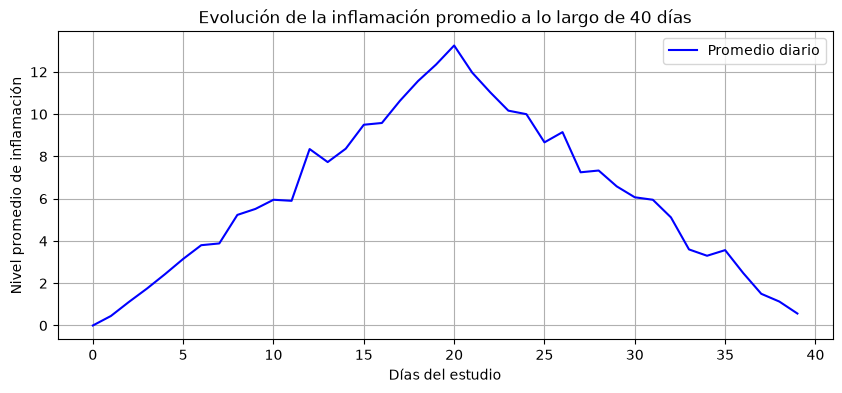

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(promedio_diario, label="Promedio diario", color="blue")
plt.title("Evolución de la inflamación promedio a lo largo de 40 días")
plt.xlabel("Días del estudio")
plt.ylabel("Nivel promedio de inflamación")
plt.grid(True)
plt.legend()
plt.show()

## 5. explicación de los resultados

**Observaciones de los datos:**
Al observar el gráfico del promedio diario, la inflamación muestra una tendencia de aumento progresivo desde el día 0 hasta alcanzar su punto máximo alrededor del día 20 (con un nivel cercano a 13). A partir de ese punto, comienza a descender de forma constante hasta volver a acercarse a cero cerca del día 40.

Aunque la línea presenta variabilidad y "ruido" diario, la macrotendencia en forma de campana o triángulo es bastante clara. Esto sugiere que, en promedio, los brotes de inflamación de los pacientes empeoran durante las primeras tres semanas antes de que cualquier tratamiento comience a hacer efecto y reduzca los síntomas hacia el final del ensayo clínico.